In [42]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl


In [43]:
voltage_deviation = ctrl.Antecedent(np.arange(0, 21, 1), 'voltage_deviation')
frequency_variation = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'frequency_variation')
load_imbalance = ctrl.Antecedent(np.arange(0, 51, 1), 'load_imbalance')
severity = ctrl.Consequent(np.arange(0, 101, 1), 'severity')

In [44]:
voltage_deviation["low"] = fuzz.trimf(voltage_deviation.universe, [0, 0, 5])
voltage_deviation["medium"] = fuzz.trimf(voltage_deviation.universe, [2, 7, 12])
voltage_deviation["high"] = fuzz.trimf(voltage_deviation.universe, [10, 20, 20])

frequency_variation["stable"] = fuzz.trimf(frequency_variation.universe, [0, 0, 0.5])
frequency_variation["unstable"] = fuzz.trimf(frequency_variation.universe, [0.3, 2, 2])

load_imbalance["balanced"] = fuzz.trimf(load_imbalance.universe, [0, 0, 20])
load_imbalance["unbalanced"] = fuzz.trimf(load_imbalance.universe, [15, 50, 50])

severity["low"] = fuzz.trimf(severity.universe, [0, 0, 30])
severity["moderate"] = fuzz.trimf(severity.universe, [20, 50, 80])
severity["high"] = fuzz.trimf(severity.universe, [70, 100, 100])


c:\Users\dulin\AppData\Local\Programs\Python\Python312\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


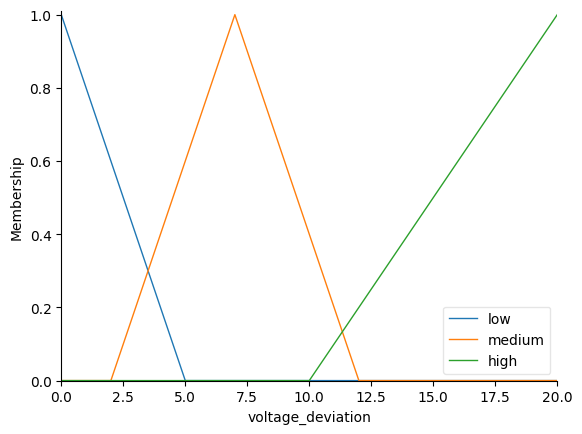

In [45]:
voltage_deviation.view()


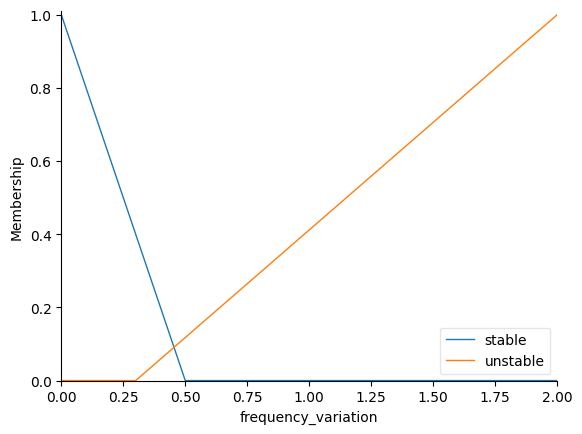

In [46]:
frequency_variation.view()

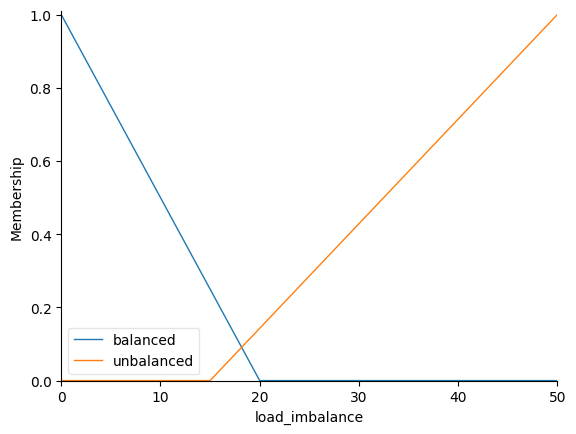

In [47]:
load_imbalance.view()

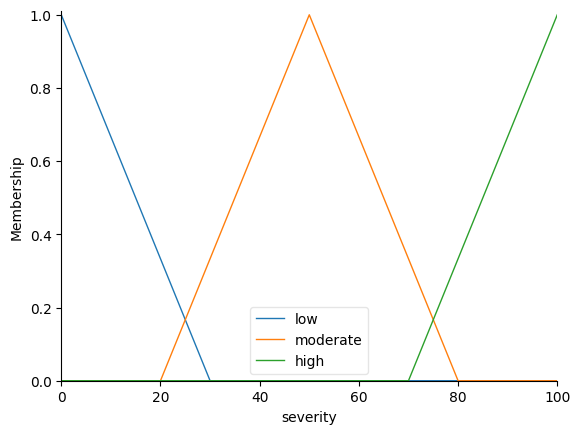

In [48]:
severity.view()

In [51]:
rule1 = ctrl.Rule(voltage_deviation['high'] | frequency_variation['unstable'] | load_imbalance['unbalanced'] , severity['high'])
rule2 = ctrl.Rule(voltage_deviation['low'] | frequency_variation['stable'] | load_imbalance['balanced'] , severity['low'])
rule3 = ctrl.Rule(voltage_deviation['high'] | frequency_variation['stable'], severity['moderate'])
rule4 = ctrl.Rule(voltage_deviation['high'] | load_imbalance['balanced'] , severity['moderate'])
rule5 = ctrl.Rule(voltage_deviation['medium'] | frequency_variation['unstable'] | load_imbalance['unbalanced'] , severity['moderate'])



In [54]:
severity_ctrl = ctrl.ControlSystem([rule1, rule2, rule3 , rule4 , rule5])

In [55]:
severity_level = ctrl.ControlSystemSimulation(severity_ctrl)

In [56]:
severity_level.input['voltage_deviation'] = 15
severity_level.input['frequency_variation'] = 1
severity_level.input['load_imbalance'] = 25

severity_level.compute()

62.46835443037974


c:\Users\dulin\AppData\Local\Programs\Python\Python312\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


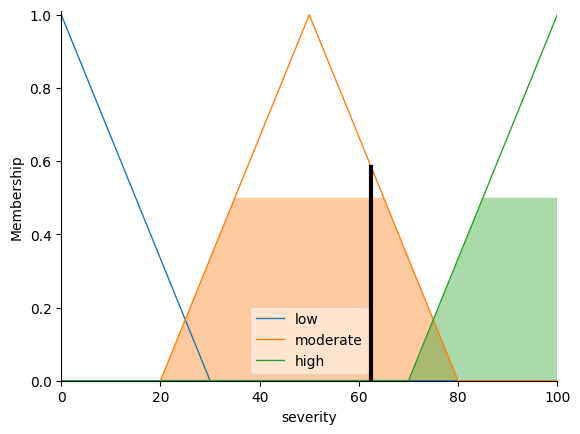

In [60]:
print(severity_level.output['severity'])
severity.view(sim = severity_level)